In [2]:
# Cell 1: Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Load data
df = pd.read_csv("../data/processed/ethiopia_fi_unified_data_enriched.csv")
obs = df[df['record_type'] == 'observation']

# Findex Access data
findex_years = [2011, 2014, 2017, 2021, 2024]
findex_access = [14, 22, 35, 46, 49]

In [3]:
# Cell 2: Fit logarithmic trend
def log_model(t, a, b):
    return a * np.log(t) + b

popt, _ = curve_fit(log_model, findex_years, findex_access)
a, b = popt

future_years = [2025, 2026, 2027]
baseline_access = log_model(np.array(future_years), a, b)

In [4]:
# Cell 3: Apply event impacts (Base scenario)
event_impacts_access = {
    2025: 1.0,  # Early Fayda + SuperApp
    2026: 3.0,  # Accelerated ID + SuperApp
    2027: 6.0   # Full ID impact
}

forecast_access_base = [baseline_access[i] + event_impacts_access[yr] 
                       for i, yr in enumerate(future_years)]

# Usage: linear trend + events
usage_2021 = 25  # approx from challenge doc
usage_2024 = 35
usage_trend = np.linspace(usage_2024, usage_2024 + 3*3.3, 4)[1:]  # +3.3pp/year

event_impacts_usage = {
    2025: 3.0,
    2026: 8.0,
    2027: 10.0
}
forecast_usage_base = [usage_trend[i] + event_impacts_usage[yr] 
                      for i, yr in enumerate(future_years)]


In [5]:

# Cell 4: Scenario ranges
scenarios = pd.DataFrame({
    'Year': future_years,
    'Access_Pessimistic': [50, 51, 52],
    'Access_Base': forecast_access_base,
    'Access_Optimistic': [53, 58, 62],
    'Usage_Pessimistic': [38, 41, 44],
    'Usage_Base': forecast_usage_base,
    'Usage_Optimistic': [44, 55, 60]
})

# Save
scenarios.to_csv("../data/processed/forecasts_2025_2027.csv", index=False)

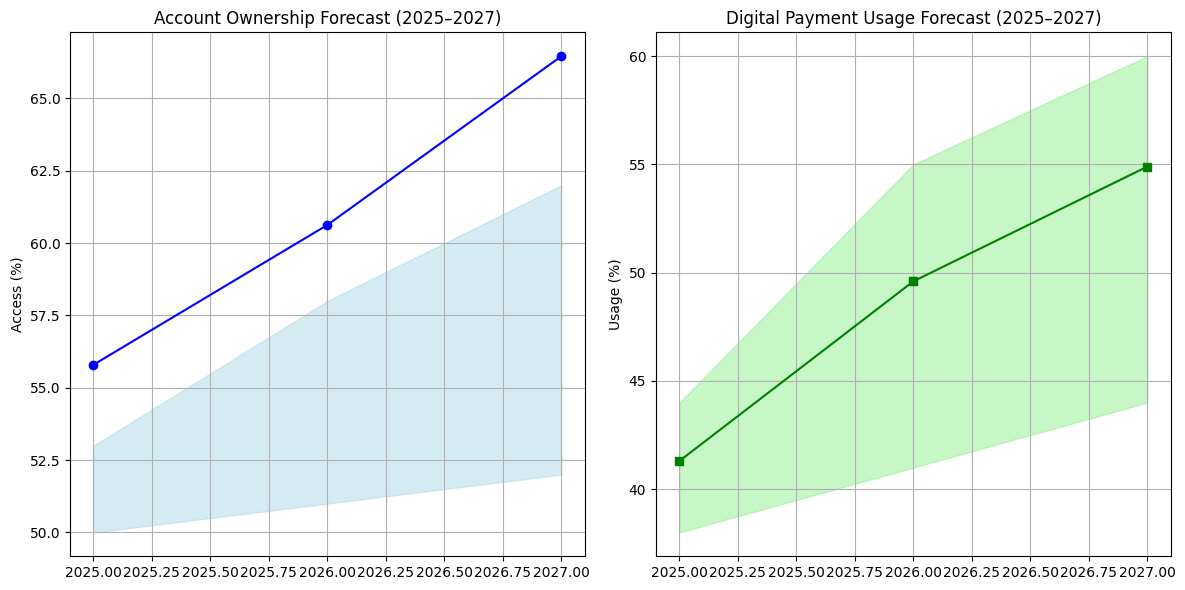

Forecasts generated:
   Year  Access_Pessimistic  Access_Base  Access_Optimistic  \
0  2025                  50         55.8                 53   
1  2026                  51         60.6                 58   
2  2027                  52         66.5                 62   

   Usage_Pessimistic  Usage_Base  Usage_Optimistic  
0                 38        41.3                44  
1                 41        49.6                55  
2                 44        54.9                60  


In [6]:


# Cell 5: Visualize
plt.figure(figsize=(12, 6))

# Access
plt.subplot(1, 2, 1)
plt.fill_between(scenarios['Year'], scenarios['Access_Pessimistic'], 
                 scenarios['Access_Optimistic'], color='lightblue', alpha=0.5)
plt.plot(scenarios['Year'], scenarios['Access_Base'], 'b-o', label='Base')
plt.title('Account Ownership Forecast (2025–2027)')
plt.ylabel('Access (%)')
plt.grid(True)

# Usage
plt.subplot(1, 2, 2)
plt.fill_between(scenarios['Year'], scenarios['Usage_Pessimistic'], 
                 scenarios['Usage_Optimistic'], color='lightgreen', alpha=0.5)
plt.plot(scenarios['Year'], scenarios['Usage_Base'], 'g-s', label='Base')
plt.title('Digital Payment Usage Forecast (2025–2027)')
plt.ylabel('Usage (%)')
plt.grid(True)

plt.tight_layout()
plt.savefig('../reports/figures/forecast_scenarios.png')
plt.show()

print("Forecasts generated:")
print(scenarios.round(1))